<a href="https://colab.research.google.com/github/nadiia2302/etl-book-sales-analytics/blob/main/data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import yaml
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
users = pd.read_csv('/content/drive/MyDrive/Data_Engineering/data/DATA1/users.csv')
users


,id,name,address,phone,email
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",(462) 385-4294,mckinley.rowe@harber.example
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",913.466.4487,francisco@murray-cronin.test
2,46407,Denny Goyette LLD,"Apt. 174 39450 Mohr Rapids, Port Neomistad, AL...",(801) 970-3335,marguerita@wuckert.test
3,44602,Zackary Heller,"Apt. 608 74228 Bogan Valley, South Stepanieshi...",895.829.5417,annabelle@hessel.test
4,45828,Jess Beier,"2716 Jacobi Path, Ziemanntown, SC 65624-4660",(113) 784-3410,minh@hettinger.example
...,...,...,...,...,...
3288,45131,Dr. Dulce Welch,"7640 Reichel Island, Swaniawskichester, VA 384...",397-216-6952,deetta_hilll@schaden.test
3289,44840,Ted Aufderhar Esq.,NaN,424 718 8383,shella.pouros@murazik.example
3290,45538,Irmgard Erdman,NaN,178.866.0267,dana@leuschke.example
3291,45097,Makeda Schmeler Ret.,"Suite 412 6556 Arnold Turnpike, Cummerataview,...",784.918.2549,daren_haag@kling.example


In [ ]:
users_copy = users.copy()

In [ ]:
users['phone'] = users['phone'].str.replace("(","").str.replace(")","").str.replace(".","").str.replace(" ","").str.replace("-","").str.replace(",","")

In [ ]:
users['email'] = users['email'].str.lower()

In [ ]:
users

,id,name,address,phone,email
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",4623854294,mckinley.rowe@harber.example
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",9134664487,francisco@murray-cronin.test
2,46407,Denny Goyette LLD,"Apt. 174 39450 Mohr Rapids, Port Neomistad, AL...",8019703335,marguerita@wuckert.test
3,44602,Zackary Heller,"Apt. 608 74228 Bogan Valley, South Stepanieshi...",8958295417,annabelle@hessel.test
4,45828,Jess Beier,"2716 Jacobi Path, Ziemanntown, SC 65624-4660",1137843410,minh@hettinger.example
...,...,...,...,...,...
3288,45131,Dr. Dulce Welch,"7640 Reichel Island, Swaniawskichester, VA 384...",3972166952,deetta_hilll@schaden.test
3289,44840,Ted Aufderhar Esq.,NaN,4247188383,shella.pouros@murazik.example
3290,45538,Irmgard Erdman,NaN,1788660267,dana@leuschke.example
3291,45097,Makeda Schmeler Ret.,"Suite 412 6556 Arnold Turnpike, Cummerataview,...",7849182549,daren_haag@kling.example


In [ ]:
users['phone'] = pd.to_numeric(users['phone'])

In [ ]:
users.dtypes

,0
id,int64
name,object
address,object
phone,int64
email,object


In [ ]:
print(users.isnull().any())

id         False
name       False
address     True
phone      False
email      False
dtype: bool


In [ ]:
garbage_values = ["NULL", "null", "None", "none", "", " ","NaN"]
users['address']= users['address'].replace(garbage_values, np.nan)
users['address']= users['address'].fillna('unknown')

In [ ]:
users

,id,name,address,phone,email
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",4623854294,mckinley.rowe@harber.example
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",9134664487,francisco@murray-cronin.test
2,46407,Denny Goyette LLD,"Apt. 174 39450 Mohr Rapids, Port Neomistad, AL...",8019703335,marguerita@wuckert.test
3,44602,Zackary Heller,"Apt. 608 74228 Bogan Valley, South Stepanieshi...",8958295417,annabelle@hessel.test
4,45828,Jess Beier,"2716 Jacobi Path, Ziemanntown, SC 65624-4660",1137843410,minh@hettinger.example
...,...,...,...,...,...
3288,45131,Dr. Dulce Welch,"7640 Reichel Island, Swaniawskichester, VA 384...",3972166952,deetta_hilll@schaden.test
3289,44840,Ted Aufderhar Esq.,unknown,4247188383,shella.pouros@murazik.example
3290,45538,Irmgard Erdman,unknown,1788660267,dana@leuschke.example
3291,45097,Makeda Schmeler Ret.,"Suite 412 6556 Arnold Turnpike, Cummerataview,...",7849182549,daren_haag@kling.example


In [ ]:
users.dtypes

,0
id,int64
name,object
address,object
phone,int64
email,object


In [ ]:
users.drop_duplicates(keep = "first").shape


(3293, 5)

In [ ]:
print(users.duplicated(subset=['name','email','phone']).sum())

52


In [ ]:
users.shape

(3293, 5)

In [ ]:
users = users.drop_duplicates(subset=['phone','email','name'])

In [ ]:
users.shape

(3241, 5)

In [ ]:
users = users.drop_duplicates(subset=['phone','address','name'])

In [ ]:
users.shape

(3204, 5)

In [ ]:
users = users.drop_duplicates(subset=['email','address','name'])

In [ ]:
users.shape

(3165, 5)

In [ ]:
users = users.drop_duplicates(subset=['phone','email','address'])

In [ ]:
users.shape

(3125, 5)

In [ ]:
users

,id,name,address,phone,email
0,44533,Hoyt Carter,"Apt. 300 8604 Ashlyn Wells, Effertzstad, ID 02997",4623854294,mckinley.rowe@harber.example
1,46128,Marco Kulas,"Apt. 538 816 Bechtelar Ferry, Lincolnhaven, KS...",9134664487,francisco@murray-cronin.test
2,46407,Denny Goyette LLD,"Apt. 174 39450 Mohr Rapids, Port Neomistad, AL...",8019703335,marguerita@wuckert.test
3,44602,Zackary Heller,"Apt. 608 74228 Bogan Valley, South Stepanieshi...",8958295417,annabelle@hessel.test
4,45828,Jess Beier,"2716 Jacobi Path, Ziemanntown, SC 65624-4660",1137843410,minh@hettinger.example
...,...,...,...,...,...
3287,46096,Pa Berge V,"Apt. 532 57301 Aide Hill, Lake Errolport, KY 2...",4169712923,porter@sauer-lockman.test
3288,45131,Dr. Dulce Welch,"7640 Reichel Island, Swaniawskichester, VA 384...",3972166952,deetta_hilll@schaden.test
3289,44840,Ted Aufderhar Esq.,unknown,4247188383,shella.pouros@murazik.example
3290,45538,Irmgard Erdman,unknown,1788660267,dana@leuschke.example


In [ ]:
with open('/content/drive/MyDrive/Data_Engineering/data/DATA1/books.yaml') as file:
  books_list = yaml.safe_load(file)

In [ ]:
books = pd.DataFrame(books_list)

In [ ]:
books.head()

,:id,:title,:author,:genre,:publisher,:year
0,19199,The Yellow Meads of Asphodel,Carolyne West,Classic,Mainstream Publishing,2009
1,19398,From Here to Eternity,"Rep. Heath Stiedemann, Gino Welch, Haydee Larson",Short story,Vintage Books,2001
2,19483,Eyeless in Gaza,Vannessa Price,Biography/Autobiography,Pavilion Books,1886
3,19506,Precious Bane,Miss Yong Wyman,Realistic fiction,New English Library,2021
4,19570,City of God,Travis Moore,Suspense/Thriller,Bellevue Literary Press,1847


In [ ]:
books.dtypes

,0
:id,int64
:title,object
:author,object
:genre,object
:publisher,object
:year,object


In [ ]:
print(books.isnull().any())

:id           False
:title        False
:author       False
:genre        False
:publisher     True
:year          True
dtype: bool


In [ ]:
books[':year'] = pd.to_numeric(books[':year'], errors='coerce')
books[':year'] = books[':year'].fillna(0).astype('int64')

In [ ]:

garbage_values = ["NULL", "null", "None", "none", "", " ","NaN"]

books[':publisher'] = books[':publisher'].replace(garbage_values, np.nan)

In [ ]:
books[':publisher'] = books[':publisher'].fillna("unknown")

In [ ]:
books

,:id,:title,:author,:genre,:publisher,:year
0,19199,The Yellow Meads of Asphodel,Carolyne West,Classic,Mainstream Publishing,2009
1,19398,From Here to Eternity,"Rep. Heath Stiedemann, Gino Welch, Haydee Larson",Short story,Vintage Books,2001
2,19483,Eyeless in Gaza,Vannessa Price,Biography/Autobiography,Pavilion Books,1886
3,19506,Precious Bane,Miss Yong Wyman,Realistic fiction,New English Library,2021
4,19570,City of God,Travis Moore,Suspense/Thriller,Bellevue Literary Press,1847
...,...,...,...,...,...,...
748,19246,Eternal Sunshine of the Spotless Mind,Carisa Blick,Realistic fiction,Victor Gollancz Ltd,2020
749,19452,Command & Conquer: Tiberium Alliances,"Numbers Howell DDS, Tyson Treutel",Mythopoeia,Shire Books,1986
750,18843,Ice Climbers,"Jenice Bartell, Raye Watsica",Humor,unknown,1990
751,19494,Mad Max: Fury Road,Blythe Bernhard,Speech,Packt Publishing,2005


In [ ]:
books.dtypes

,0
:id,int64
:title,object
:author,object
:genre,object
:publisher,object
:year,int64


In [ ]:
books

,:id,:title,:author,:genre,:publisher,:year
0,19199,The Yellow Meads of Asphodel,Carolyne West,Classic,Mainstream Publishing,2009
1,19398,From Here to Eternity,"Rep. Heath Stiedemann, Gino Welch, Haydee Larson",Short story,Vintage Books,2001
2,19483,Eyeless in Gaza,Vannessa Price,Biography/Autobiography,Pavilion Books,1886
3,19506,Precious Bane,Miss Yong Wyman,Realistic fiction,New English Library,2021
4,19570,City of God,Travis Moore,Suspense/Thriller,Bellevue Literary Press,1847
...,...,...,...,...,...,...
748,19246,Eternal Sunshine of the Spotless Mind,Carisa Blick,Realistic fiction,Victor Gollancz Ltd,2020
749,19452,Command & Conquer: Tiberium Alliances,"Numbers Howell DDS, Tyson Treutel",Mythopoeia,Shire Books,1986
750,18843,Ice Climbers,"Jenice Bartell, Raye Watsica",Humor,unknown,1990
751,19494,Mad Max: Fury Road,Blythe Bernhard,Speech,Packt Publishing,2005


In [ ]:
books.drop_duplicates(keep = False).shape

(753, 6)

In [ ]:
books = books.drop_duplicates(subset=[':author',':title',':genre'])
books.shape


(693, 6)

In [ ]:
books = books.drop_duplicates(subset=[':author',':title'])
books.shape

(693, 6)

In [ ]:
books = books.drop_duplicates(subset=[':title'])
books.shape

(693, 6)

In [ ]:
books

,:id,:title,:author,:genre,:publisher,:year
0,19199,The Yellow Meads of Asphodel,Carolyne West,Classic,Mainstream Publishing,2009
1,19398,From Here to Eternity,"Rep. Heath Stiedemann, Gino Welch, Haydee Larson",Short story,Vintage Books,2001
2,19483,Eyeless in Gaza,Vannessa Price,Biography/Autobiography,Pavilion Books,1886
3,19506,Precious Bane,Miss Yong Wyman,Realistic fiction,New English Library,2021
4,19570,City of God,Travis Moore,Suspense/Thriller,Bellevue Literary Press,1847
...,...,...,...,...,...,...
748,19246,Eternal Sunshine of the Spotless Mind,Carisa Blick,Realistic fiction,Victor Gollancz Ltd,2020
749,19452,Command & Conquer: Tiberium Alliances,"Numbers Howell DDS, Tyson Treutel",Mythopoeia,Shire Books,1986
750,18843,Ice Climbers,"Jenice Bartell, Raye Watsica",Humor,unknown,1990
751,19494,Mad Max: Fury Road,Blythe Bernhard,Speech,Packt Publishing,2005


In [ ]:
unique_authors = len(books[':author'].unique())


In [ ]:
orders = pd.read_parquet('/content/drive/MyDrive/Data_Engineering/data/DATA1/orders.parquet')

In [ ]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping
0,71389,47288,18976,2,27.00$,10/01/24 10:38:08 A.M.,None
1,66343,47049,19403,1,€50¢50,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599"
2,72606,46685,19500,1,USD 45.99,"22:13:35,2025-07-02",
3,68462,45336,18992,1,€ 71.00,2025-10-20 16:25:20,
4,72691,45311,19388,1,52.25 $,"08:48:47 A.M.,28-August-2024",None
...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99 EUR,04:51:02;04/06/25,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2..."
11233,72164,46481,18864,2,$71¢00,12:38:25 A.M. 2024-06-20,NULL
11234,70697,44686,19083,5,€50.,"11-Dec-2024, 14:52",NULL
11235,64646,46203,19190,1,44.75USD,11:09;05/17/25,


In [ ]:
orders.dtypes

,0
id,int64
user_id,int64
book_id,int64
quantity,int32
unit_price,object
timestamp,object
shipping,object


In [ ]:
# transform unit_price
orders['unit_price'] = orders['unit_price'].str.replace("¢",".")

In [ ]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping
0,71389,47288,18976,2,27.00$,10/01/24 10:38:08 A.M.,None
1,66343,47049,19403,1,€50.50,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599"
2,72606,46685,19500,1,USD 45.99,"22:13:35,2025-07-02",
3,68462,45336,18992,1,€ 71.00,2025-10-20 16:25:20,
4,72691,45311,19388,1,52.25 $,"08:48:47 A.M.,28-August-2024",None
...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99 EUR,04:51:02;04/06/25,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2..."
11233,72164,46481,18864,2,$71.00,12:38:25 A.M. 2024-06-20,NULL
11234,70697,44686,19083,5,€50.,"11-Dec-2024, 14:52",NULL
11235,64646,46203,19190,1,44.75USD,11:09;05/17/25,


In [ ]:
# clean and split unit_price to currency and price as a value
unit_price = orders.unit_price.tolist()
clean_prices = []
currencies = []
for up in unit_price:
  if "USD" in up or "$" in up:
    clean_unit_price = up.replace("$","").replace("USD","")
    currency = "$"
  elif "EUR" in up or "€" in up:
    clean_unit_price = up.replace("€","").replace("EUR","")
    currency = "€"
  else:
    currency = "$"
  clean_prices.append(clean_unit_price)
  currencies.append(currency)

In [ ]:
orders['unit_price'] = clean_prices
orders['currency'] = currencies

In [ ]:
orders['unit_price'] = orders['unit_price'].str.rstrip('.')
orders['unit_price'] = pd.to_numeric(orders['unit_price'])

In [ ]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,currency
0,71389,47288,18976,2,27.00,10/01/24 10:38:08 A.M.,None,$
1,66343,47049,19403,1,50.50,10:14;19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599",€
2,72606,46685,19500,1,45.99,"22:13:35,2025-07-02",,$
3,68462,45336,18992,1,71.00,2025-10-20 16:25:20,,€
4,72691,45311,19388,1,52.25,"08:48:47 A.M.,28-August-2024",None,$
...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99,04:51:02;04/06/25,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",€
11233,72164,46481,18864,2,71.00,12:38:25 A.M. 2024-06-20,NULL,$
11234,70697,44686,19083,5,50.00,"11-Dec-2024, 14:52",NULL,€
11235,64646,46203,19190,1,44.75,11:09;05/17/25,,$


In [ ]:
orders['timestamp'] = orders['timestamp'].str.replace(";"," ").str.replace(","," ")

In [ ]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,currency
0,71389,47288,18976,2,27.00,10/01/24 10:38:08 A.M.,None,$
1,66343,47049,19403,1,50.50,10:14 19-Oct-2024,"4940 Arnoldo Keys, West Arnette, KS 77599",€
2,72606,46685,19500,1,45.99,22:13:35 2025-07-02,,$
3,68462,45336,18992,1,71.00,2025-10-20 16:25:20,,€
4,72691,45311,19388,1,52.25,08:48:47 A.M. 28-August-2024,None,$
...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99,04:51:02 04/06/25,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",€
11233,72164,46481,18864,2,71.00,12:38:25 A.M. 2024-06-20,NULL,$
11234,70697,44686,19083,5,50.00,11-Dec-2024 14:52,NULL,€
11235,64646,46203,19190,1,44.75,11:09 05/17/25,,$


In [ ]:
orders.dtypes

,0
id,int64
user_id,int64
book_id,int64
quantity,int32
unit_price,float64
timestamp,object
shipping,object
currency,object


In [ ]:
# transform timestamp
orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')

/tmp/ipykernel_3659/2691118659.py:2: FutureWarning: Parsed string "10/01/24 10:38:08 A.M." included an un-recognized timezone "M". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')
/tmp/ipykernel_3659/2691118659.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')
/tmp/ipykernel_3659/2691118659.py:2: FutureWarning: Parsed string "08:48:47 A.M. 28-August-2024" included an un-recognized timezone "M". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recogn

In [ ]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,currency
0,71389,47288,18976,2,27.00,2024-10-01 10:38:08,None,$
1,66343,47049,19403,1,50.50,2024-10-19 10:14:00,"4940 Arnoldo Keys, West Arnette, KS 77599",€
2,72606,46685,19500,1,45.99,2025-07-02 22:13:35,,$
3,68462,45336,18992,1,71.00,2025-10-20 16:25:20,,€
4,72691,45311,19388,1,52.25,2024-08-28 08:48:47,None,$
...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99,2025-04-06 04:51:02,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",€
11233,72164,46481,18864,2,71.00,2024-06-20 00:38:25,NULL,$
11234,70697,44686,19083,5,50.00,2024-12-11 14:52:00,NULL,€
11235,64646,46203,19190,1,44.75,2025-05-17 11:09:00,,$


In [ ]:
orders.dtypes

,0
id,int64
user_id,int64
book_id,int64
quantity,int32
unit_price,float64
timestamp,datetime64[ns]
shipping,object
currency,object


In [ ]:
print(orders.isnull().any())

id            False
user_id       False
book_id       False
quantity      False
unit_price    False
timestamp     False
shipping       True
currency      False
dtype: bool


In [ ]:

garbage_values = ["NULL", "null", "None", "none", "", " ","NaN"]
orders['shipping'] = orders['shipping'].replace(garbage_values, np.nan)

In [ ]:
orders['shipping'] = orders['shipping'].fillna("unknown")

In [ ]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,currency
0,71389,47288,18976,2,27.00,2024-10-01 10:38:08,unknown,$
1,66343,47049,19403,1,50.50,2024-10-19 10:14:00,"4940 Arnoldo Keys, West Arnette, KS 77599",€
2,72606,46685,19500,1,45.99,2025-07-02 22:13:35,unknown,$
3,68462,45336,18992,1,71.00,2025-10-20 16:25:20,unknown,€
4,72691,45311,19388,1,52.25,2024-08-28 08:48:47,unknown,$
...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99,2025-04-06 04:51:02,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",€
11233,72164,46481,18864,2,71.00,2024-06-20 00:38:25,unknown,$
11234,70697,44686,19083,5,50.00,2024-12-11 14:52:00,unknown,€
11235,64646,46203,19190,1,44.75,2025-05-17 11:09:00,unknown,$


In [ ]:
orders.drop_duplicates(keep = "first").shape


(11237, 8)

In [ ]:
orders.duplicated().sum()

np.int64(0)

In [ ]:
orders.duplicated(subset=['user_id', 'book_id', 'quantity','timestamp']).sum()

np.int64(0)

In [ ]:
orders.duplicated(subset=['user_id', 'book_id','timestamp']).sum()

np.int64(0)

In [ ]:
orders.duplicated(subset=['user_id', 'book_id','timestamp']).sum()

np.int64(0)

In [ ]:
orders.shape

(11237, 8)

In [ ]:
orders = orders.copy()
orders['paid_price'] = orders['quantity'] * orders['unit_price']
orders.loc[orders.currency == "€", 'paid_price'] = orders['quantity'] * orders['unit_price']*1.2


In [ ]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,currency,paid_price
0,71389,47288,18976,2,27.00,2024-10-01 10:38:08,unknown,$,54.000
1,66343,47049,19403,1,50.50,2024-10-19 10:14:00,"4940 Arnoldo Keys, West Arnette, KS 77599",€,60.600
2,72606,46685,19500,1,45.99,2025-07-02 22:13:35,unknown,$,45.990
3,68462,45336,18992,1,71.00,2025-10-20 16:25:20,unknown,€,85.200
4,72691,45311,19388,1,52.25,2024-08-28 08:48:47,unknown,$,52.250
...,...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99,2025-04-06 04:51:02,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",€,69.588
11233,72164,46481,18864,2,71.00,2024-06-20 00:38:25,unknown,$,142.000
11234,70697,44686,19083,5,50.00,2024-12-11 14:52:00,unknown,€,300.000
11235,64646,46203,19190,1,44.75,2025-05-17 11:09:00,unknown,$,44.750


In [ ]:
orders['date'] = orders['timestamp'].dt.date

In [ ]:
orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,currency,paid_price,date
0,71389,47288,18976,2,27.00,2024-10-01 10:38:08,unknown,$,54.000,2024-10-01
1,66343,47049,19403,1,50.50,2024-10-19 10:14:00,"4940 Arnoldo Keys, West Arnette, KS 77599",€,60.600,2024-10-19
2,72606,46685,19500,1,45.99,2025-07-02 22:13:35,unknown,$,45.990,2025-07-02
3,68462,45336,18992,1,71.00,2025-10-20 16:25:20,unknown,€,85.200,2025-10-20
4,72691,45311,19388,1,52.25,2024-08-28 08:48:47,unknown,$,52.250,2024-08-28
...,...,...,...,...,...,...,...,...,...,...
11232,70045,45032,18966,1,57.99,2025-04-06 04:51:02,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",€,69.588,2025-04-06
11233,72164,46481,18864,2,71.00,2024-06-20 00:38:25,unknown,$,142.000,2024-06-20
11234,70697,44686,19083,5,50.00,2024-12-11 14:52:00,unknown,€,300.000,2024-12-11
11235,64646,46203,19190,1,44.75,2025-05-17 11:09:00,unknown,$,44.750,2025-05-17


In [ ]:
daily_revenue = orders.groupby('date')['paid_price'].sum()

In [ ]:
daily_revenue

,paid_price
date,
2024-01-05,62.000
2024-01-08,69.500
2024-01-10,76.500
2024-01-12,86.388
2024-01-18,73.000
...,...
2025-11-09,29.700
2025-12-02,59.750
2025-12-04,76.800


In [ ]:
top_5_days = daily_revenue.nlargest(5)

In [ ]:
top_5_days

,paid_price
date,
2024-12-17,57011.458
2024-11-03,46656.298
2025-03-23,39120.974
2024-09-06,33490.168
2025-01-25,31732.458


In [ ]:
print("The real amount of unique users: ", len(users))

The real amount of unique users:  3125


In [ ]:
print("The unique sets of authors are:", unique_authors)

The unique sets of authors are: 374


In [ ]:
merged_books_orders = pd.merge(orders, books, left_on = 'book_id', right_on = ':id', how = 'inner' )
merged_books_orders

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,currency,paid_price,date,:id,:title,:author,:genre,:publisher,:year
0,71389,47288,18976,2,27.00,2024-10-01 10:38:08,unknown,$,54.000,2024-10-01,18976,Cinema Paradiso,Pres. Doug Donnelly,Fable,Oberon Books,0
1,66343,47049,19403,1,50.50,2024-10-19 10:14:00,"4940 Arnoldo Keys, West Arnette, KS 77599",€,60.600,2024-10-19,19403,Of Human Bondage,Cassi Herman,Folklore,Parragon,1978
2,72606,46685,19500,1,45.99,2025-07-02 22:13:35,unknown,$,45.990,2025-07-02,19500,Hotel California,Delbert Emmerich II,Legend,Book League of America,1984
3,68462,45336,18992,1,71.00,2025-10-20 16:25:20,unknown,€,85.200,2025-10-20,18992,Mother Night,Sondra O'Reilly,Folklore,Left Book Club,1978
4,72691,45311,19388,1,52.25,2024-08-28 08:48:47,unknown,$,52.250,2024-08-28,19388,Raiders of the Lost Ark,Frankie Vandervort,Humor,Newnes,1981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10332,70045,45032,18966,1,57.99,2025-04-06 04:51:02,"Apt. 657 809 Karisa Dale, Port Moseshire, IN 2...",€,69.588,2025-04-06,18966,The Bodyguard,Rob Veum,Mythopoeia,Ignatius Press,1998
10333,72164,46481,18864,2,71.00,2024-06-20 00:38:25,unknown,$,142.000,2024-06-20,18864,High School Musical,Randall Brakus,Western,Carlton Books,2009
10334,70697,44686,19083,5,50.00,2024-12-11 14:52:00,unknown,€,300.000,2024-12-11,19083,Pokémon Y,"Agustin Stanton III, Keneth Crist",Mythopoeia,ECW Press,1983
10335,64646,46203,19190,1,44.75,2025-05-17 11:09:00,unknown,$,44.750,2025-05-17,19190,The Golden Apples of the Sun,"Rossana Koelpin, Maynard Strosin CPA, Normand ...",Metafiction,Cisco Press,1990


In [ ]:
# the most popular sold books by books
popular_books = merged_books_orders.groupby(['book_id',':title',':author'])['quantity'].sum()
popular_books.nlargest(n=10)

,,,quantity
book_id,:title,:author,
19026,Call of Duty: Black Ops,Marvel O'Hara,51
18846,Brütal Legend,Preston Hyatt,46
19544,Can't Slow Down,Alex Ledner,46
18928,Pokémon Sword,Lorean Koch,44
19167,Tapestry,Ms. Numbers Kris,44
18840,Monster Hunter: World,Cathy Kovacek PhD,43
18926,System Shock,Cathy Kovacek PhD,43
19236,Fargo,"Heath Mayer, Ms. Elwood Kuhlman",43
19498,I Sing the Body Electric,"Elijah Bernhard, Msgr. Frances Fritsch, Rudy Wisozk",41


In [ ]:
# the most popular sold books by authors
popular_authors = merged_books_orders.groupby([':id',':title',':author'])['quantity'].sum()
popular_authors.nlargest(n=10)

,,,quantity
:id,:title,:author,
19026,Call of Duty: Black Ops,Marvel O'Hara,51
18846,Brütal Legend,Preston Hyatt,46
19544,Can't Slow Down,Alex Ledner,46
18928,Pokémon Sword,Lorean Koch,44
19167,Tapestry,Ms. Numbers Kris,44
18840,Monster Hunter: World,Cathy Kovacek PhD,43
18926,System Shock,Cathy Kovacek PhD,43
19236,Fargo,"Heath Mayer, Ms. Elwood Kuhlman",43
19498,I Sing the Body Electric,"Elijah Bernhard, Msgr. Frances Fritsch, Rudy Wisozk",41


In [ ]:
merged_users_orders = pd.merge(orders, users, left_on = "user_id", right_on = "id", how = "inner")


In [ ]:
top_customers = merged_users_orders.groupby(['email','phone','name','address'])['paid_price'].sum()
top_customers

,,,,paid_price
email,phone,name,address,
aaron@gutkowski.test,4531706271,Dr. Carmina Funk,"8166 Casey Center, East Carey, RI 30966-7466",923.240
aaron_pfeffer@tremblay-metz.example,8536751778,Reinaldo Halvorson,"27213 Mohr Wall, West Myrafurt, OK 21759-3074",618.650
abdul.kub@oconnell.example,6777525240,Ian Nolan LLD,"62408 Tom Trail, Lake Emmett, KS 45406",110.250
abdul@mcglynn-aufderhar.test,2083616052,Francisco McGlynn,unknown,92.140
abdul@windler.test,7651701756,Bertie Homenick MD,"346 Thurman Drives, Kyleeberg, SC 12019",323.040
...,...,...,...,...
zenaida_feest@kunze.test,3463688160,August Pacocha,"Suite 321 16570 Patricia Parkways, Hudsonchester, AZ 72447",217.200
zenobia@mayert-herzog.test,9630670115,Shenna Lang,"81623 Doloris Island, New Van, SD 95948",7376.188
zita@crist-brakus.example,9116787202,Veda Bernier,"880 Riley Causeway, Kiehnview, MA 58579",164.678


In [ ]:
top_customers.nlargest(1)

,,,,paid_price
email,phone,name,address,
jon@lindgren.example,8029048840,Dean Mayer,"Apt. 234 157 Candyce Dam, North Deidra, CA 96389-7424",37609.7


In [ ]:
best_email = top_customers.nlargest(1).index[0][0]
print(best_email)

jon@lindgren.example


In [ ]:
best_name = top_customers.nlargest(1).index[0][2]
print(best_name)

Dean Mayer


In [ ]:
best_customer = users_copy[users_copy['name'] == best_name]['id'].unique().tolist()
best_customer

[45800]

In [ ]:
best_customer = users_copy[users_copy['email'] == best_email]['id'].unique().tolist()
best_customer

[45800]

In [ ]:
daily_revenue

,paid_price
date,
2024-01-05,62.000
2024-01-08,69.500
2024-01-10,76.500
2024-01-12,86.388
2024-01-18,73.000
...,...
2025-11-09,29.700
2025-12-02,59.750
2025-12-04,76.800


<Figure size 1000x500 with 0 Axes>

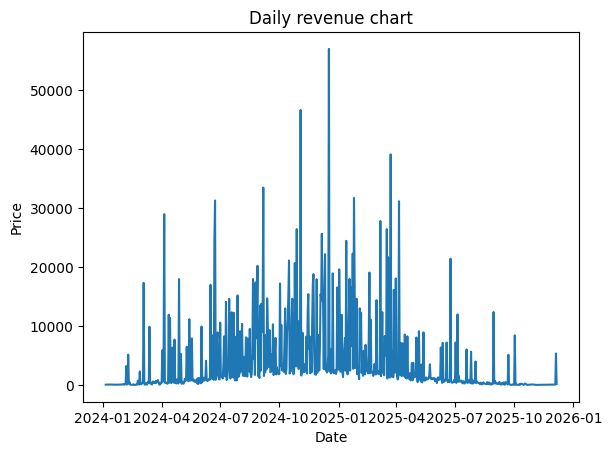

<Figure size 1000x500 with 0 Axes>

In [ ]:
daily_revenue.plot( kind = "line")
plt.title('Daily revenue chart')
plt.xlabel('Date')
plt.ylabel('Price')
plt.figure(figsize=(10, 5))

In [ ]:
users.to_csv('users_final.csv', index=False)
orders.to_csv('orders_final.csv', index=False)
books.to_csv('books_final.csv', index=False)